# Treinamento Não Supervisionado

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

df = pd.read_csv("../data/silver/flights_delay_cancelled.csv", sep=",")

# Selecionar variáveis numéricas relevantes
features = [
    "DISTANCE",
    "AIR_TIME",
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "TAXI_OUT",
    "TAXI_IN"
]

data = df[features].dropna()

# Normalizar dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

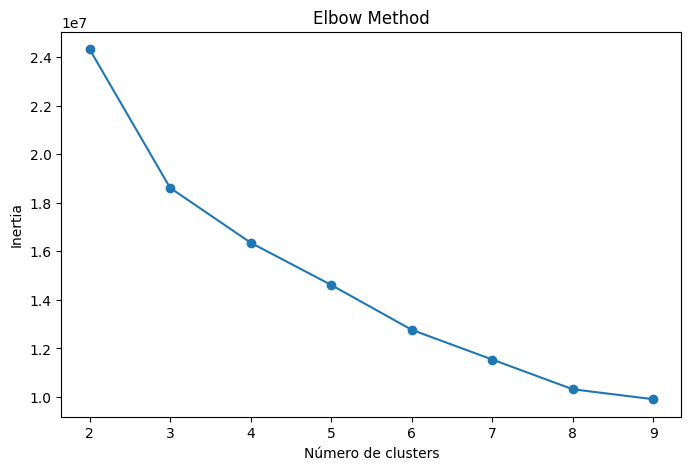

In [188]:
inertia = []

K = range(2,10)

for k in K:
    
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=60000,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")

plt.show()

In [189]:
kmeans = MiniBatchKMeans(
    n_clusters=3,
    batch_size=60000,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

data["cluster"] = clusters

In [190]:
score = silhouette_score(X_scaled, clusters, sample_size=60000, random_state=42)

print("Silhouette Score:", score)

Silhouette Score: 0.41643610883919735


In [191]:
pca = PCA(n_components=2)
pca.fit(X_scaled)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [192]:
X_pca = pca.transform(X_scaled)

In [193]:
X_scaled.shape

(5231130, 6)

In [194]:
X_pca.shape

(5231130, 2)

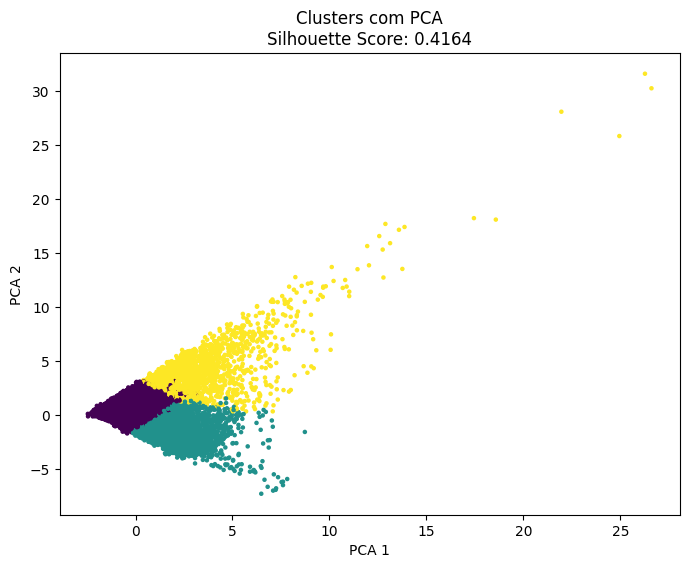

In [195]:
sample = np.random.choice(len(X_pca), 50000, replace=False)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[sample,0],
    X_pca[sample,1],
    c=clusters[sample],
    cmap="viridis",
    s=5
)
plt.title(f'Clusters com PCA\nSilhouette Score: {score:.4f}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [196]:
cluster_summary = data.groupby("cluster").mean()

print(cluster_summary)

            DISTANCE    AIR_TIME  DEPARTURE_DELAY  ARRIVAL_DELAY   TAXI_OUT  \
cluster                                                                       
0         574.583897   84.043270         3.589713      -1.008838  15.513185   
1        1822.935251  231.375289         5.462888      -1.376232  17.438267   
2         790.009588  110.794869       148.860659     149.886464  20.827302   

          TAXI_IN  
cluster            
0        7.063768  
1        8.621633  
2        8.739435  


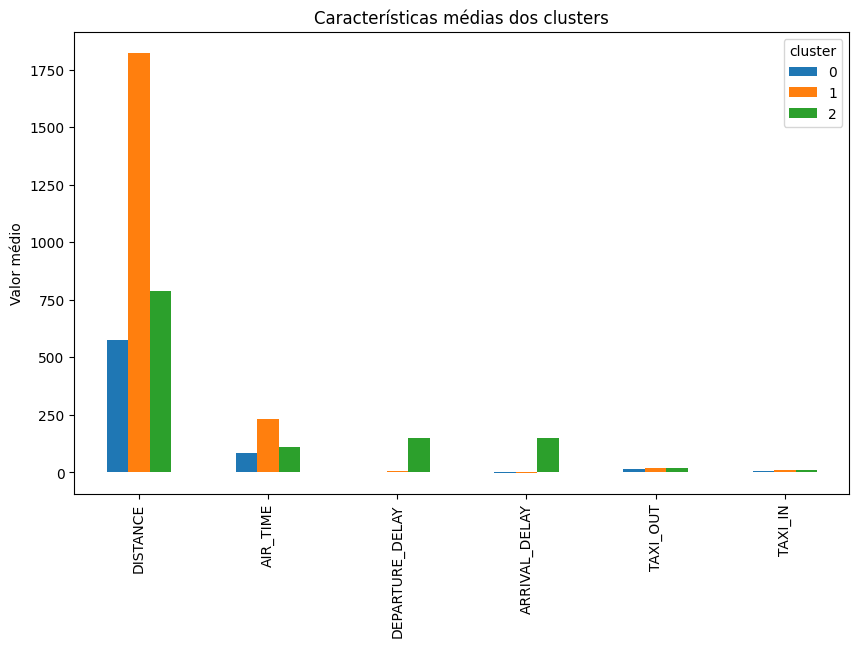

In [197]:
cluster_summary.T.plot(kind="bar", figsize=(10,6))
plt.title("Características médias dos clusters")
plt.ylabel("Valor médio")
plt.show()

### Teste

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ===============================
# 1 - Carregar dados
# ===============================

df = pd.read_csv("../data/silver/flights_delay_cancelled.csv", sep=",")

# ===============================
# 2 - Selecionar variáveis
# (evitando variáveis muito correlacionadas)
# ===============================

features = [
    "DISTANCE",
    "TAXI_OUT",
    "TAXI_IN",
    "DEPARTURE_DELAY",
    "AIRLINE_DELAY",
    "WEATHER_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

data = df[features].dropna()



In [200]:
# ===============================
# 3 - Tratar outliers
# ===============================

data["DEPARTURE_DELAY"] = data["DEPARTURE_DELAY"].clip(-60, 300)

# ===============================
# 4 - Escalonamento robusto
# ===============================

scaler = RobustScaler()
X_scaled = scaler.fit_transform(data)

# ===============================
# 5 - Redução de dimensionalidade
# ===============================

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# ===============================
# 6 - Testar melhor número de clusters
# ===============================

print("Testando número de clusters...\n")

for k in range(2,8):

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=60000,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        clusters,
        sample_size=60000,
        random_state=42
    )

    print(f"K = {k} | Silhouette = {score:.4f}")


# ===============================
# 7 - Modelo final
# ===============================

kmeans = MiniBatchKMeans(
        n_clusters=4,
        batch_size=60000,
        random_state=42,
        n_init=10
    )

clusters = kmeans.fit_predict(X_pca)

data["cluster"] = clusters



Testando número de clusters...

K = 2 | Silhouette = 0.9270
K = 3 | Silhouette = 0.8608
K = 4 | Silhouette = 0.7117
K = 5 | Silhouette = 0.6703
K = 6 | Silhouette = 0.4370
K = 7 | Silhouette = 0.2486


In [201]:
score = silhouette_score(
    X_pca,
    clusters,
    sample_size=60000,
    random_state=42
)

print("\nSilhouette Score Final:", score)




Silhouette Score Final: 0.7117134940123669


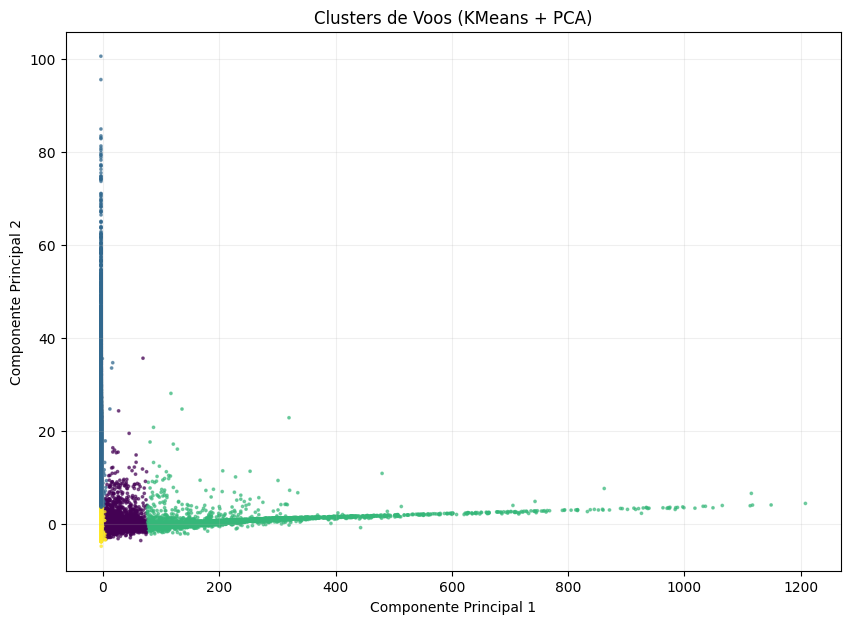

In [202]:
# ===============================
# 8 - Visualização com PCA
# ===============================

pca2 = PCA(n_components=2)
X_vis = pca2.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=clusters,
    cmap="viridis",
    s=3,
    alpha=0.6
)

plt.title("Clusters de Voos (KMeans + PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.grid(alpha=0.2)

plt.show()